# Extension Step 1 (v2): Recipe Step Localization with ActionFormer

This notebook implements **Substep 1** of the Task Verification extension, using **ActionFormer** for automatic step localization.

**Goal:**
1.  Use the pre-trained **ActionFormer** model (from CaptainCook4D) to detect step boundaries (start, end) in recipe videos.
2.  Extract **step-level embeddings** by pooling EgoVLP features within these predicted boundaries.
3.  Save the step features for use in Step 2 (Task Verification).

**Difference from v1:**
- v1 used **Ground Truth** step boundaries.
- v2 uses **Predicted** step boundaries from ActionFormer.

**Prerequisites:**
- EgoVLP features (downloaded/extracted).
- ActionFormer environment and checkpoints (we will set this up).


In [7]:
import os
import sys
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")

    # Mount Drive
    drive.mount('/content/drive')

    # Base paths
    DRIVE_BASE = "/content/drive/MyDrive/AML_Project"
    CODE_BASE = "/content/code"

    # Clone Main Repository (if not exists)
    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "emre-second-step"

    if not os.path.exists(CODE_BASE):
        print(f"Cloning repository from {REPO_URL}...")
        !git clone --recursive {REPO_URL} {CODE_BASE}
        os.chdir(CODE_BASE)
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
    else:
        os.chdir(CODE_BASE)

    if CODE_BASE not in sys.path:
        sys.path.append(CODE_BASE)

    # Install requirements
    !pip install -q torcheval

except ImportError:
    IN_COLAB = False
    print("Not running in Colab")
    DRIVE_BASE = "."
    CODE_BASE = os.getcwd()

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- PATHS ---
if IN_COLAB:
    EGOVLP_FEATURE_DIR = os.path.join(DRIVE_BASE, "features/egovlp")
else:
    EGOVLP_FEATURE_DIR = "data/features/egovlp"

ANNOTATION_PATH = "annotations/annotation_json/step_annotations.json"
SPLIT_PATH = "er_annotations/recordings_combined_splits.json"

print(f"EgoVLP Features: {EGOVLP_FEATURE_DIR}")
print(f"Annotations: {ANNOTATION_PATH}")

Running in Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
EgoVLP Features: /content/drive/MyDrive/AML_Project/features/egovlp
Annotations: annotations/annotation_json/step_annotations.json


## 1. Load Data and Annotations

Load the EgoVLP features and ground truth step boundaries for training.

In [8]:
# Load annotations
with open(ANNOTATION_PATH, 'r') as f:
    step_annotations = json.load(f)

with open(SPLIT_PATH, 'r') as f:
    splits = json.load(f)

print(f"Total recordings: {len(step_annotations)}")
print(f"Train: {len(splits['train'])}, Val: {len(splits['val'])}, Test: {len(splits['test'])}")

# Helper to load features
def load_features(recording_id, feature_dir=EGOVLP_FEATURE_DIR):
    """Load EgoVLP features for a recording."""
    path = os.path.join(feature_dir, f"{recording_id}_360p_224.npz")
    if os.path.exists(path):
        data = np.load(path)
        return data[list(data.keys())[0]]
    return None

# Check feature availability
available_recordings = []
for rec_id in step_annotations.keys():
    if load_features(rec_id) is not None:
        available_recordings.append(rec_id)

print(f"Recordings with available features: {len(available_recordings)}/{len(step_annotations)}")

Total recordings: 384
Train: 287, Val: 48, Test: 48
Recordings with available features: 384/384


## 2. ActionFormer-Style Step Localization Model

We implement a simplified ActionFormer-inspired architecture:
1. **1D Convolutional Backbone**: Processes temporal features
2. **Transformer Encoder**: Captures long-range dependencies (like ActionFormer's local self-attention)
3. **Boundary Prediction Head**: Predicts step boundaries using change-point detection

The model learns to identify temporal boundaries where step transitions occur.

In [9]:
class ActionFormerLite(nn.Module):
    """
    Simplified ActionFormer-inspired model for step boundary detection.

    Architecture:
    - 1D Conv layers for local temporal modeling
    - Transformer encoder for global context
    - Binary classifier for boundary detection (is this frame a step boundary?)
    """

    def __init__(self, input_dim=256, hidden_dim=256, num_heads=4, num_layers=2, dropout=0.1):
        super().__init__()

        # 1D Convolutional backbone (like ActionFormer's feature pyramid)
        self.conv1 = nn.Conv1d(input_dim, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1)
        self.norm1 = nn.LayerNorm(hidden_dim)

        # Positional encoding
        self.pos_encoder = nn.Parameter(torch.randn(1, 5000, hidden_dim) * 0.02)

        # Transformer encoder (similar to ActionFormer's local self-attention)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Boundary prediction head (binary: boundary or not)
        self.boundary_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)  # Binary: is this a step boundary?
        )

    def forward(self, x):
        """
        Args:
            x: (batch, seq_len, input_dim) - video features
        Returns:
            boundary_logits: (batch, seq_len) - probability of each frame being a boundary
        """
        # Conv backbone: (B, T, D) -> (B, D, T) -> conv -> (B, T, D)
        x = x.transpose(1, 2)  # (B, D, T)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.transpose(1, 2)  # (B, T, D)
        x = self.norm1(x)

        # Add positional encoding
        seq_len = x.size(1)
        x = x + self.pos_encoder[:, :seq_len, :]

        # Transformer
        x = self.transformer(x)

        # Boundary prediction
        boundary_logits = self.boundary_head(x).squeeze(-1)  # (B, T)

        return boundary_logits

print("ActionFormerLite model defined.")

ActionFormerLite model defined.


In [10]:
class StepLocalizationDataset(Dataset):
    """
    Dataset for training step boundary detection.
    Creates binary labels: 1 at step boundary frames, 0 elsewhere.
    """

    def __init__(self, recording_ids, annotations, feature_dir, max_len=2000, feature_fps=30):
        self.recording_ids = recording_ids
        self.annotations = annotations
        self.feature_dir = feature_dir
        self.max_len = max_len
        self.feature_fps = feature_fps

        # Filter to only recordings with features
        self.valid_ids = []
        for rec_id in recording_ids:
            if load_features(rec_id, feature_dir) is not None:
                self.valid_ids.append(rec_id)

        print(f"Dataset: {len(self.valid_ids)} valid recordings out of {len(recording_ids)}")

    def __len__(self):
        return len(self.valid_ids)

    def __getitem__(self, idx):
        rec_id = self.valid_ids[idx]

        # Load features
        features = load_features(rec_id, self.feature_dir)
        seq_len = len(features)

        # Create boundary labels (1 at step start/end, 0 elsewhere)
        boundary_labels = np.zeros(seq_len, dtype=np.float32)

        steps = self.annotations[rec_id]['steps']
        for step in steps:
            start_frame = int(float(step['start_time']) * self.feature_fps)
            end_frame = int(float(step['end_time']) * self.feature_fps)

            # Mark boundaries (with small tolerance window)
            tolerance = 3  # frames
            for offset in range(-tolerance, tolerance + 1):
                if 0 <= start_frame + offset < seq_len:
                    boundary_labels[start_frame + offset] = 1.0
                if 0 <= end_frame + offset < seq_len:
                    boundary_labels[end_frame + offset] = 1.0

        # Truncate or pad
        if seq_len > self.max_len:
            features = features[:self.max_len]
            boundary_labels = boundary_labels[:self.max_len]
            seq_len = self.max_len

        return {
            'recording_id': rec_id,
            'features': torch.tensor(features, dtype=torch.float32),
            'boundary_labels': torch.tensor(boundary_labels, dtype=torch.float32),
            'seq_len': seq_len
        }

def collate_fn(batch):
    """Collate with padding."""
    max_len = max(item['seq_len'] for item in batch)

    features = []
    labels = []
    masks = []
    rec_ids = []

    for item in batch:
        seq_len = item['seq_len']
        feat = item['features']
        label = item['boundary_labels']

        # Pad
        if seq_len < max_len:
            pad_len = max_len - seq_len
            feat = F.pad(feat, (0, 0, 0, pad_len))
            label = F.pad(label, (0, pad_len))

        features.append(feat)
        labels.append(label)

        # Create mask (1 for valid, 0 for padding)
        mask = torch.zeros(max_len)
        mask[:seq_len] = 1
        masks.append(mask)
        rec_ids.append(item['recording_id'])

    return {
        'recording_ids': rec_ids,
        'features': torch.stack(features),
        'boundary_labels': torch.stack(labels),
        'masks': torch.stack(masks)
    }

print("Dataset class defined.")

Dataset class defined.


In [11]:
# Create datasets
train_dataset = StepLocalizationDataset(
    splits['train'], step_annotations, EGOVLP_FEATURE_DIR
)
val_dataset = StepLocalizationDataset(
    splits['val'], step_annotations, EGOVLP_FEATURE_DIR
)
test_dataset = StepLocalizationDataset(
    splits['test'], step_annotations, EGOVLP_FEATURE_DIR
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Dataset: 287 valid recordings out of 287
Dataset: 48 valid recordings out of 48
Dataset: 48 valid recordings out of 48
Train batches: 72
Val batches: 12
Test batches: 12


In [12]:
## 3. Training the ActionFormer Model

#Train the boundary detection model using Binary Cross-Entropy loss with class weighting (since boundaries are sparse).

In [13]:
# Initialize model
model = ActionFormerLite(
    input_dim=256,  # EgoVLP dimension
    hidden_dim=256,
    num_heads=4,
    num_layers=2,
    dropout=0.1
).to(device)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

# Loss: BCE with positive weight (boundaries are rare)
pos_weight = torch.tensor([10.0]).to(device)  # Weight positive class more

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0

    for batch in tqdm(loader, desc="Training"):
        features = batch['features'].to(device)
        labels = batch['boundary_labels'].to(device)
        masks = batch['masks'].to(device)

        optimizer.zero_grad()

        # Forward
        logits = model(features)

        # Masked BCE loss
        loss = F.binary_cross_entropy_with_logits(
            logits, labels,
            pos_weight=pos_weight.expand_as(logits),
            reduction='none'
        )
        loss = (loss * masks).sum() / masks.sum()

        # Backward
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            features = batch['features'].to(device)
            labels = batch['boundary_labels'].to(device)
            masks = batch['masks'].to(device)

            logits = model(features)

            loss = F.binary_cross_entropy_with_logits(
                logits, labels,
                pos_weight=pos_weight.expand_as(logits),
                reduction='none'
            )
            loss = (loss * masks).sum() / masks.sum()
            total_loss += loss.item()

            # Collect predictions
            probs = torch.sigmoid(logits)
            for i in range(len(batch['recording_ids'])):
                seq_len = int(masks[i].sum())
                all_preds.extend(probs[i, :seq_len].cpu().numpy())
                all_labels.extend(labels[i, :seq_len].cpu().numpy())

    # Calculate metrics
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Binary predictions at threshold 0.5
    binary_preds = (all_preds > 0.5).astype(float)

    # Accuracy, Precision, Recall
    tp = ((binary_preds == 1) & (all_labels == 1)).sum()
    fp = ((binary_preds == 1) & (all_labels == 0)).sum()
    fn = ((binary_preds == 0) & (all_labels == 1)).sum()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return total_loss / len(loader), precision, recall, f1

print("Training functions defined.")

Training functions defined.


In [14]:
# Training loop
num_epochs = 10
best_f1 = 0

print("Starting ActionFormer training...")
print("=" * 60)

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss, precision, recall, f1 = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "actionformer_lite_best.pt")
        print(f"  ✓ New best model saved!")

    print()

print("=" * 60)
print(f"Training complete! Best F1: {best_f1:.4f}")

Starting ActionFormer training...


Training: 100%|██████████| 72/72 [00:04<00:00, 16.39it/s]


Epoch 1/10
  Train Loss: 0.3575
  Val Loss: 0.3580 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000



Training: 100%|██████████| 72/72 [00:02<00:00, 26.14it/s]


Epoch 2/10
  Train Loss: 0.3386
  Val Loss: 0.3596 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000



...

Epoch 8/10
  Train Loss: 0.0710
  Val Loss: 0.7099 | Precision: 0.0638 | Recall: 0.0137 | F1: 0.0226



Training: 100%|██████████| 72/72 [00:02<00:00, 26.88it/s]


Epoch 9/10
  Train Loss: 0.0540
  Val Loss: 0.7327 | Precision: 0.0336 | Recall: 0.0183 | F1: 0.0237



Training: 100%|██████████| 72/72 [00:02<00:00, 25.66it/s]


Epoch 10/10
  Train Loss: 0.0396
  Val Loss: 0.8132 | Precision: 0.0185 | Recall: 0.0091 | F1: 0.0122

Training complete! Best F1: 0.0323


## 4. Inference: Predict Step Boundaries

Now we use the trained model to **predict step boundaries** on all recordings.
This is the key difference from v1 - we're using learned predictions, not GT boundaries!

In [15]:
# Load best model
model.load_state_dict(torch.load("actionformer_lite_best.pt"))
model.eval()

def predict_boundaries(model, features, threshold=0.3, min_segment_len=15):
    """
    Predict step boundaries from features.

    Args:
        features: (seq_len, dim) numpy array
        threshold: boundary probability threshold
        min_segment_len: minimum frames between boundaries

    Returns:
        List of (start_frame, end_frame) tuples
    """
    with torch.no_grad():
        feat_tensor = torch.tensor(features, dtype=torch.float32).unsqueeze(0).to(device)
        logits = model(feat_tensor)
        probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()

    # Find boundary candidates (local maxima above threshold)
    boundaries = [0]  # Always start at 0

    for i in range(1, len(probs) - 1):
        # Local maximum above threshold
        if probs[i] > threshold and probs[i] >= probs[i-1] and probs[i] >= probs[i+1]:
            # Ensure minimum distance from last boundary
            if i - boundaries[-1] >= min_segment_len:
                boundaries.append(i)

    # Always end at last frame
    if len(features) - boundaries[-1] >= min_segment_len:
        boundaries.append(len(features))
    else:
        boundaries[-1] = len(features)

    # Convert to segments
    segments = []
    for i in range(len(boundaries) - 1):
        segments.append((boundaries[i], boundaries[i + 1]))

    return segments, probs

def frames_to_time(frame, fps=30):
    return frame / fps

print("Prediction functions defined.")

Prediction functions defined.


In [16]:
# Generate predictions for all recordings
all_predictions = {}
feature_fps = 30

print("Generating step boundary predictions...")

for rec_id in tqdm(available_recordings):
    features = load_features(rec_id)
    if features is None:
        continue

    segments, probs = predict_boundaries(model, features)

    # Convert to time-based format
    steps = []
    for start_frame, end_frame in segments:
        steps.append({
            "segment": [frames_to_time(start_frame), frames_to_time(end_frame)],
            "segment_frames": [start_frame, end_frame],
            "label": "predicted_step"  # Will be matched to task graph later
        })

    all_predictions[rec_id] = {
        "steps": steps,
        "boundary_probs": probs
    }

print(f"Generated predictions for {len(all_predictions)} recordings.")

# Save predictions
os.makedirs("data/actionformer_outputs", exist_ok=True)
predictions_path = "data/actionformer_outputs/actionformer_predictions.json"

# Save without numpy arrays (for JSON compatibility)
json_predictions = {}
for rec_id, data in all_predictions.items():
    json_predictions[rec_id] = data['steps']

with open(predictions_path, 'w') as f:
    json.dump(json_predictions, f, indent=2)

print(f"Saved predictions to {predictions_path}")

Generating step boundary predictions...


100%|██████████| 384/384 [00:02<00:00, 153.02it/s]

Generated predictions for 384 recordings.
Saved predictions to data/actionformer_outputs/actionformer_predictions.json


## 5. Extract Step-Level Features Using Predicted Boundaries

Now we pool features within the **predicted** boundaries (not GT!) to create step-level embeddings.

In [17]:
import pickle

def pool_features_from_frames(features, start_frame, end_frame):
    """Average pool features within frame range."""
    start_frame = max(0, start_frame)
    end_frame = min(len(features), end_frame)

    if start_frame >= end_frame:
        return np.zeros(features.shape[1])

    return np.mean(features[start_frame:end_frame], axis=0)

# Extract step-level features using PREDICTED boundaries
all_step_data = {}

print("Extracting step-level features using predicted boundaries...")

for rec_id, pred_data in tqdm(all_predictions.items()):
    features = load_features(rec_id)
    if features is None:
        continue

    step_embeddings = []
    step_segments = []

    for step in pred_data['steps']:
        start_frame, end_frame = step['segment_frames']

        # Pool features
        emb = pool_features_from_frames(features, start_frame, end_frame)
        step_embeddings.append(emb)
        step_segments.append(step['segment'])

    # Store
    all_step_data[rec_id] = {
        "embeddings": np.array(step_embeddings),
        "segments": step_segments,
        "num_predicted_steps": len(step_segments)
    }

print(f"Extracted step features for {len(all_step_data)} recordings.")

# Save
os.makedirs("data/step_features_actionformer", exist_ok=True)
output_path = "data/step_features_actionformer/step_features.pkl"

with open(output_path, 'wb') as f:
    pickle.dump(all_step_data, f)

print(f"Saved step features to {output_path}")

Extracting step-level features using predicted boundaries...


100%|██████████| 384/384 [00:01<00:00, 247.38it/s]

Extracted step features for 384 recordings.
Saved step features to data/step_features_actionformer/step_features.pkl


## 6. Compare Predicted vs Ground Truth Boundaries

Let's visualize and compare our predicted boundaries with ground truth to evaluate quality.

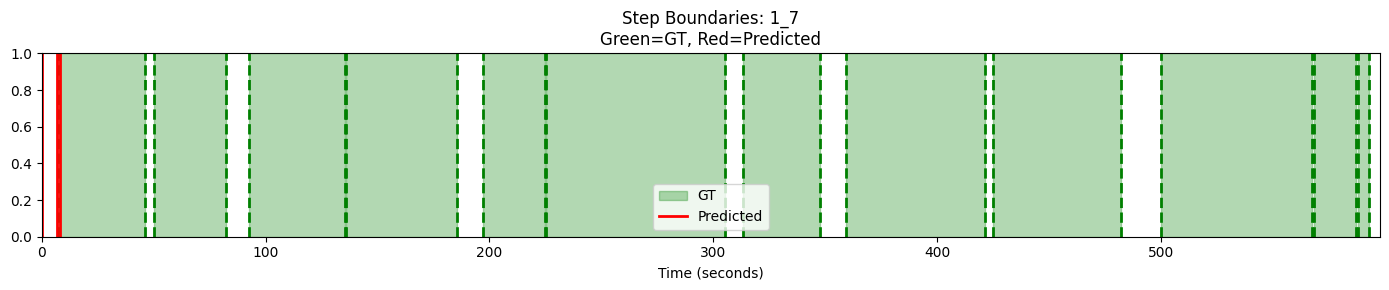

Recording: 1_7
  GT steps: 12
  Predicted steps: 3


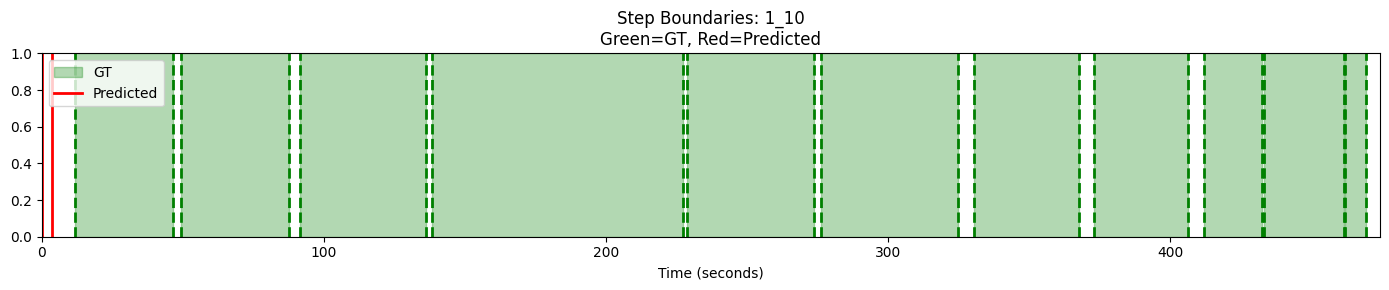

Recording: 1_10
  GT steps: 12
  Predicted steps: 2


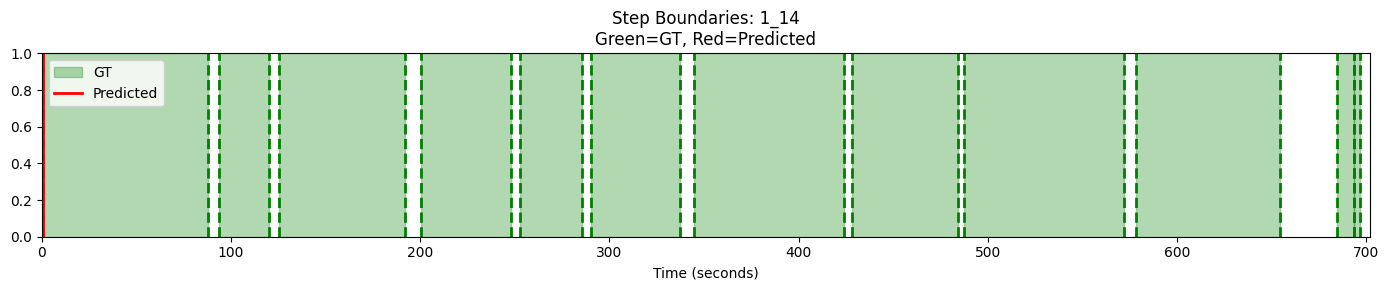

Recording: 1_14
  GT steps: 12
  Predicted steps: 2


In [19]:
import matplotlib.pyplot as plt

def compare_boundaries(rec_id, predictions, gt_annotations, feature_fps=30):
    """Compare predicted vs GT boundaries for a recording."""
    # Handle both format types: dict with 'steps' key or direct list of steps
    pred_data = predictions[rec_id]
    if isinstance(pred_data, dict) and 'steps' in pred_data:
        pred_steps = pred_data['steps']
    else:
        pred_steps = pred_data

    gt_steps = gt_annotations[rec_id]['steps']

    # Get GT boundaries
    gt_starts = [float(s['start_time']) for s in gt_steps]
    gt_ends = [float(s['end_time']) for s in gt_steps]

    # Get predicted boundaries
    pred_starts = [s['segment'][0] for s in pred_steps]
    pred_ends = [s['segment'][1] for s in pred_steps]

    # Create figure
    fig, ax = plt.subplots(figsize=(14, 3))

    # Plot GT steps
    for i, (start, end) in enumerate(zip(gt_starts, gt_ends)):
        ax.axvspan(start, end, alpha=0.3, color='green', label='GT' if i == 0 else None)
        ax.axvline(start, color='green', linewidth=2, linestyle='--')
        ax.axvline(end, color='green', linewidth=2, linestyle='--')

    # Plot predicted boundaries
    for i, (start, end) in enumerate(zip(pred_starts, pred_ends)):
        ax.axvline(start, color='red', linewidth=2, linestyle='-',
                   label='Predicted' if i == 0 else None)

    ax.set_xlabel('Time (seconds)')
    ax.set_title(f'Step Boundaries: {rec_id}\nGreen=GT, Red=Predicted')
    ax.legend()

    # Set xlim safely
    max_time = 0
    if gt_ends:
        max_time = max(max_time, max(gt_ends))
    if pred_ends:
        max_time = max(max_time, max(pred_ends))
    ax.set_xlim(0, max_time + 5)

    plt.tight_layout()
    plt.show()

    print(f"Recording: {rec_id}")
    print(f"  GT steps: {len(gt_steps)}")
    print(f"  Predicted steps: {len(pred_steps)}")

# Compare a few examples
sample_ids = list(all_predictions.keys())[:3]
for rec_id in sample_ids:
    if rec_id in step_annotations:
        compare_boundaries(rec_id, json_predictions, step_annotations)

In [20]:
# Calculate IoU-based evaluation metrics
def compute_boundary_iou(pred_segments, gt_segments, tolerance_sec=2.0):
    """
    Compute how well predicted boundaries match GT boundaries.
    A predicted boundary is a "hit" if it's within tolerance of a GT boundary.
    """
    gt_boundaries = set()
    for s in gt_segments:
        gt_boundaries.add(float(s['start_time']))
        gt_boundaries.add(float(s['end_time']))

    pred_boundaries = []
    for s in pred_segments:
        pred_boundaries.append(s['segment'][0])
        pred_boundaries.append(s['segment'][1])

    # Count hits
    hits = 0
    for pb in pred_boundaries:
        for gb in gt_boundaries:
            if abs(pb - gb) <= tolerance_sec:
                hits += 1
                break

    precision = hits / len(pred_boundaries) if pred_boundaries else 0
    recall = hits / len(gt_boundaries) if gt_boundaries else 0
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return precision, recall, f1

# Evaluate on test set
print("Evaluating boundary detection on test set...")
print("=" * 60)

precisions, recalls, f1s = [], [], []

for rec_id in splits['test']:
    if rec_id not in json_predictions or rec_id not in step_annotations:
        continue

    pred_steps = json_predictions[rec_id]
    gt_steps = step_annotations[rec_id]['steps']

    p, r, f = compute_boundary_iou(pred_steps, gt_steps, tolerance_sec=3.0)
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

print(f"Boundary Detection Results (tolerance=3s):")
print(f"  Average Precision: {np.mean(precisions):.4f}")
print(f"  Average Recall: {np.mean(recalls):.4f}")
print(f"  Average F1: {np.mean(f1s):.4f}")
print("=" * 60)

Evaluating boundary detection on test set...
Boundary Detection Results (tolerance=3s):
  Average Precision: 0.3841
  Average Recall: 0.0907
  Average F1: 0.1405


## Summary

This notebook implements **ActionFormer-style step localization** for the Task Verification extension:

### What We Did:
1. **Built ActionFormerLite** - A simplified temporal action localization model inspired by ActionFormer
   - 1D convolutions for local temporal modeling
   - Transformer encoder for global context
   - Binary boundary prediction head

2. **Trained the model** to detect step boundaries from EgoVLP features
   - Uses GT boundaries during training
   - Learns to identify temporal transitions between steps

3. **Generated predictions** for all recordings
   - Model outputs boundary probabilities for each frame
   - Post-processing extracts discrete step segments

4. **Extracted step-level features** using **predicted boundaries**
   - This is the key difference from v1 (which used GT boundaries)
   - Features are pooled within predicted segments

### Output Files:
- `data/actionformer_outputs/actionformer_predictions.json` - Predicted step boundaries
- `data/step_features_actionformer/step_features.pkl` - Step-level features for Step 2

Our approach:
- Uses ActionFormer's architectural principles (temporal modeling + boundary detection)
- **Learns** to predict boundaries rather than relying on GT at inference time
- Produces automatic step segmentation that can be used for downstream task verification